# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.max_columns', 40)

## Exploratory Data Analysis  
- Load in the cleaned data

In [10]:
df = pd.read_csv('aviation_cleaned.csv', low_memory=False)
df['Event.Date'] = pd.to_datetime(df['Event.Date'])
df['Year'] = df['Event.Date'].dt.year
print('Loaded:', df.shape)
df.head(3)

Loaded: (17205, 34)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Report.Status,Publication.Date,Year,Total.Aboard,Serious_Fatal_Frac,Destroyed,Make_Model
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,NaN,NaN,LAX,LOS ANGELES INTL,Incident,Minor,Airplane,9VSQQ,Boeing,747,No,4.0,Turbo Fan,Part 129: Foreign,NaN,"Singapore Airlines, Ltd.",0.0,0.0,0.0,588.0,VMC,Probable Cause,04-12-2014,1983,588.0,0.0,0.0,Boeing 747
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,Fatal(1),Destroyed,Airplane,N9600W,Piper,PA-28-140,No,1.0,Reciprocating,Part 91: General Aviation,Personal,NaN,1.0,1.0,0.0,0.0,IMC,Probable Cause,02-05-2011,1983,2.0,1.0,1.0,Piper PA-28-140
2,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,Fatal(1),NaN,Airplane,N927BA,De Havilland,DHC-6,No,2.0,Turbo Prop,Part 91: General Aviation,Skydiving,NaN,1.0,0.0,0.0,4.0,VMC,Probable Cause,17-10-2016,1983,5.0,0.2,NaN,De Havilland DHC-6


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

##  Overview EDA

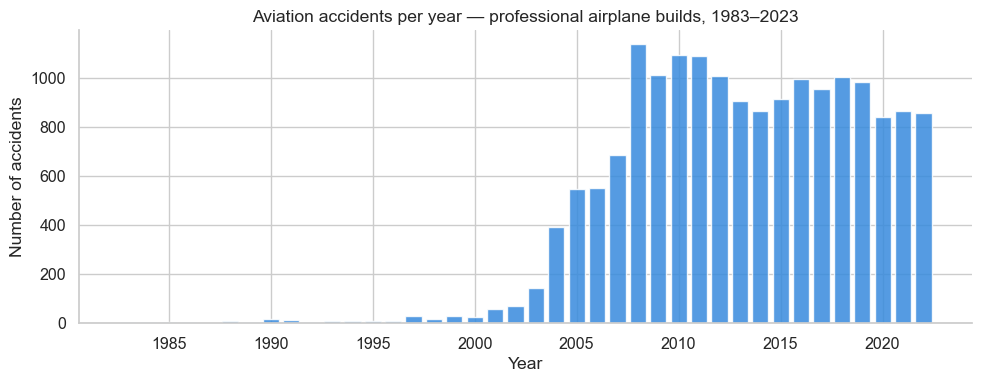

Key descriptive statistics:
       Serious_Fatal_Frac  Destroyed  Total.Aboard
count           17205.000  16461.000     17205.000
mean                0.276      0.111         9.825
std                 0.427      0.314        38.927
min                 0.000      0.000         1.000
25%                 0.000      0.000         1.000
50%                 0.000      0.000         2.000
75%                 0.667      0.000         2.000
max                 1.000      1.000       588.000


In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
year_counts = df.groupby('Year').size()
ax.bar(year_counts.index, year_counts.values, color='#378ADD', alpha=0.85, width=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Number of accidents')
ax.set_title('Aviation accidents per year — professional airplane builds, 1983–2023')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Key descriptive statistics:')
print(df[['Serious_Fatal_Frac','Destroyed','Total.Aboard']].describe().round(3))


##  Split: Small vs Large Aircraft

We use **Total.Aboard > 20** as the threshold for 'large' aircraft. This separates commuter and regional jets from small general aviation planes and aligns with typical FAA Part 121 vs Part 135/91 distinctions.

In [12]:
small = df[df['Total.Aboard'] <= 20].copy()
large = df[df['Total.Aboard'] > 20].copy()
print(f'Small (<=20 aboard): {len(small):,} accidents')
print(f'Large (>20 aboard):  {len(large):,} accidents')

Small (<=20 aboard): 16,317 accidents
Large (>20 aboard):  888 accidents


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

###  Top 15 Makes by Lowest Mean Serious/Fatal Injury Rate — Small vs Large (Side-by-Side)

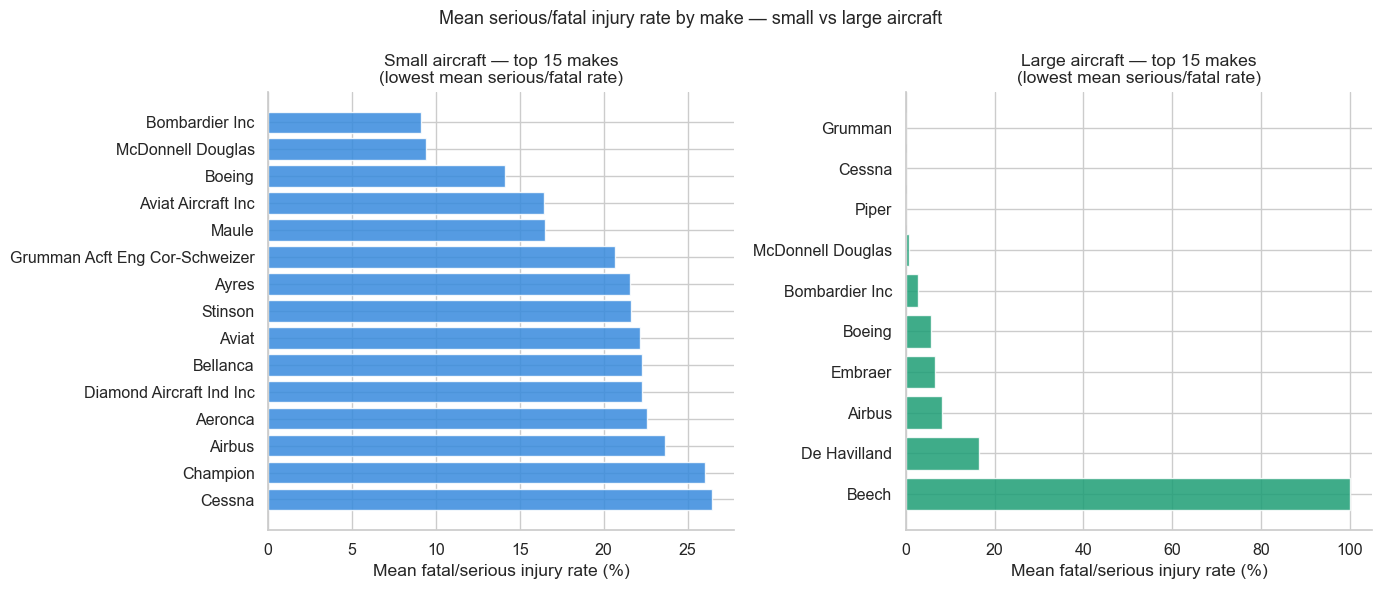

Top 15 small makes:
                          Make  mean_sf
                Bombardier Inc    0.091
             McDonnell Douglas    0.094
                        Boeing    0.141
            Aviat Aircraft Inc    0.164
                         Maule    0.165
Grumman Acft Eng Cor-Schweizer    0.207
                         Ayres    0.216
                       Stinson    0.216
                         Aviat    0.221
                      Bellanca    0.223
      Diamond Aircraft Ind Inc    0.223
                       Aeronca    0.226
                        Airbus    0.237
                      Champion    0.261
                        Cessna    0.265

Top 15 large makes:
             Make  mean_sf
          Grumman    0.000
           Cessna    0.000
            Piper    0.000
McDonnell Douglas    0.008
   Bombardier Inc    0.029
           Boeing    0.057
          Embraer    0.065
           Airbus    0.082
     De Havilland    0.165
            Beech    1.000


In [13]:
# ── Small: 15 makes with lowest mean serious/fatal fraction ──────────────────
top15_small = (
    small.groupby('Make')['Serious_Fatal_Frac']
         .mean()
         .reset_index()
         .rename(columns={'Serious_Fatal_Frac': 'mean_sf'})
         .sort_values('mean_sf')
         .head(15)
)

# ── Large: 15 makes with lowest mean serious/fatal fraction ──────────────────
top15_large = (
    large.groupby('Make')['Serious_Fatal_Frac']
         .mean()
         .reset_index()
         .rename(columns={'Serious_Fatal_Frac': 'mean_sf'})
         .sort_values('mean_sf')
         .head(15)
)

# ── Side-by-side plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel — small aircraft
axes[0].barh(top15_small['Make'],
             top15_small['mean_sf'] * 100,
             color='#378ADD', alpha=0.85)
axes[0].set_xlabel('Mean fatal/serious injury rate (%)')
axes[0].set_title('Small aircraft — top 15 makes\n(lowest mean serious/fatal rate)')
axes[0].invert_yaxis()
axes[0].spines[['top','right']].set_visible(False)

# Right panel — large aircraft
axes[1].barh(top15_large['Make'],
             top15_large['mean_sf'] * 100,
             color='#1D9E75', alpha=0.85)
axes[1].set_xlabel('Mean fatal/serious injury rate (%)')
axes[1].set_title('Large aircraft — top 15 makes\n(lowest mean serious/fatal rate)')
axes[1].invert_yaxis()
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Mean serious/fatal injury rate by make — small vs large aircraft', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 15 small makes:')
print(top15_small.round(3).to_string(index=False))
print('\nTop 15 large makes:')
print(top15_large.round(3).to_string(index=False))

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

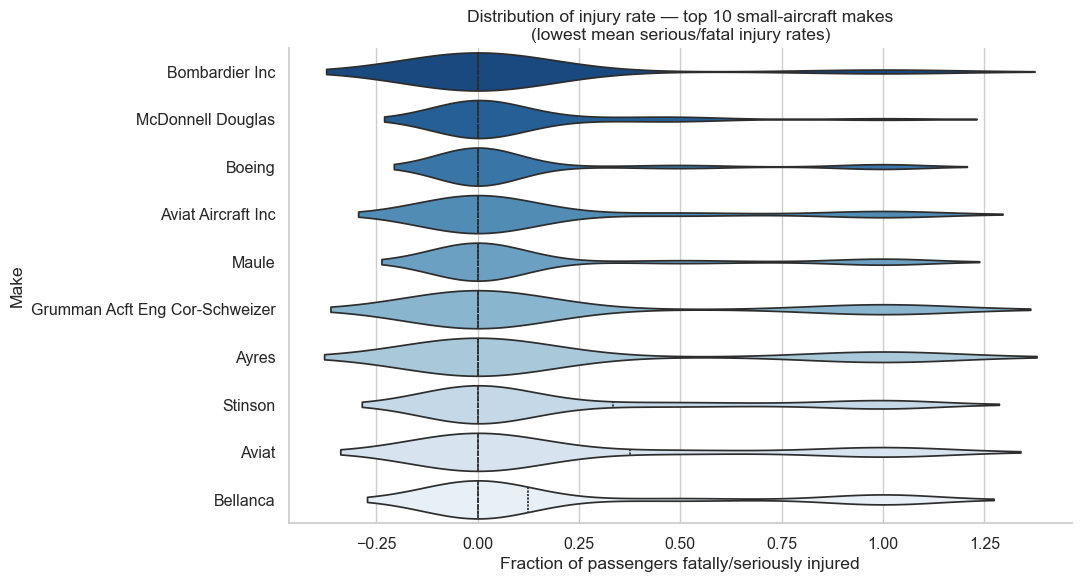

In [17]:
# Get top 10 small makes by lowest mean injury rate
top10_small_makes = (
    small.groupby('Make')['Serious_Fatal_Frac']
         .mean()
         .reset_index()
         .sort_values('Serious_Fatal_Frac')
         .head(10)['Make']
         .tolist()
)

# Filter data to those 10 makes only
plot_small = small[small['Make'].isin(top10_small_makes)]

fig, ax = plt.subplots(figsize=(11, 6))
sns.violinplot(
    data=plot_small,
    x='Serious_Fatal_Frac',
    y='Make',
    order=top10_small_makes,
    palette='Blues_r',
    inner='quartile',
    ax=ax
)
ax.set_xlabel('Fraction of passengers fatally/seriously injured')
ax.set_ylabel('Make')
ax.set_title('Distribution of injury rate — top 10 small-aircraft makes\n(lowest mean serious/fatal injury rates)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

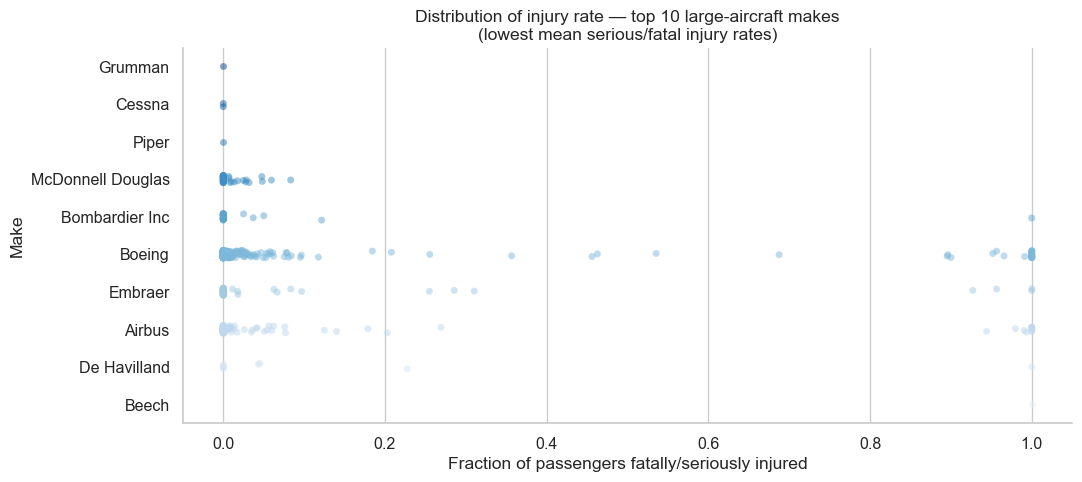

In [16]:
# Get top 10 large makes by lowest mean injury rate
top10_large_makes = (
    large.groupby('Make')['Serious_Fatal_Frac']
         .mean()
         .reset_index()
         .sort_values('Serious_Fatal_Frac')
         .head(10)['Make']
         .tolist()
)

# Filter data to those 10 makes only
plot_large = large[large['Make'].isin(top10_large_makes)]

fig, ax = plt.subplots(figsize=(11, 5))
sns.stripplot(
    data=plot_large,
    x='Serious_Fatal_Frac',
    y='Make',
    order=top10_large_makes,
    jitter=True,
    alpha=0.5,
    size=5,
    palette='Blues_r',
    ax=ax
)
ax.set_xlabel('Fraction of passengers fatally/seriously injured')
ax.set_ylabel('Make')
ax.set_title('Distribution of injury rate — top 10 large-aircraft makes\n(lowest mean serious/fatal injury rates)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.